moyenne des pentes : 0.3498  (vraie valeur : 0.35)
écart-type         : 0.0259


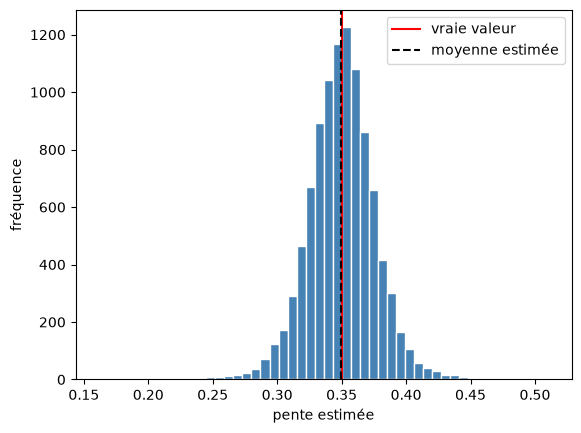

n =    6  ->  écart-type = 0.0260
n =   30  ->  écart-type = 0.0093
n =  100  ->  écart-type = 0.0049
n =  500  ->  écart-type = 0.0022


In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def simuler_pente(n, pente_vraie=0.35, sigma=0.002):
    x = rng.uniform(0.01, 0.15, n)
    y = pente_vraie * x + rng.normal(0, sigma, n)         # vraie droite + bruit
    # estimateur OLS de la pente = cov(x, y) / var(x)
    return np.mean((x - x.mean()) * (y - y.mean())) / np.mean((x - x.mean())**2)

# Monte Carlo : on répète l'expérience 10 000 fois
pentes = np.array([simuler_pente(6) for _ in range(10_000)])
print(f"moyenne des pentes : {pentes.mean():.4f}  (vraie valeur : 0.35)")
print(f"écart-type         : {pentes.std():.4f}")

# 1) Sans biais : la moyenne tombe sur 0.35
plt.hist(pentes, bins=50, color="steelblue", edgecolor="white")
plt.axvline(0.35, color="red", label="vraie valeur")
plt.axvline(pentes.mean(), color="black", ls="--", label="moyenne estimée")
plt.legend(); plt.xlabel("pente estimée"); plt.ylabel("fréquence"); plt.show()

# 2) Consistance : l'écart-type diminue quand n augmente
for n in [6, 30, 100, 500]:
    s = np.array([simuler_pente(n) for _ in range(10_000)]).std()
    print(f"n = {n:>4}  ->  écart-type = {s:.4f}")